In [27]:
# import library
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [28]:
# load dataset with tf.keras
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
# print shape
print(train_images.shape,train_labels.shape, test_images.shape, test_labels.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


index : 0
label :  5
image


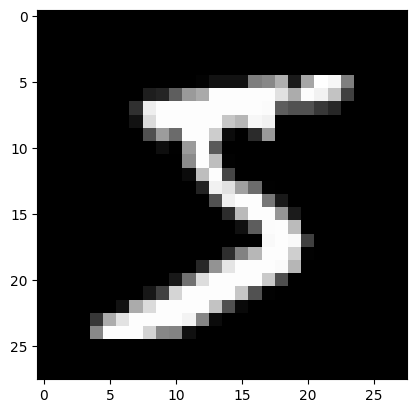

In [29]:
# check image
i = 0
print("index : " + str(i))
print("label : ", train_labels[i])
print("image")    
plt.imshow(train_images[i], cmap='gray')
plt.show()

In [30]:
def random_choice_and_split_train_valid(array,axis,random_seed,ratio):
    array_random_choiced = np.random.default_rng(random_seed).choice(array,size=len(array),axis=axis)
    train = array_random_choiced[0:int(np.ceil(len(array)*ratio))]
    valid = array_random_choiced[int(np.ceil(len(array)*ratio)):]
    return train, valid

In [31]:
train_images_random, valid_images_random = random_choice_and_split_train_valid(train_images,axis=0 ,random_seed=0, ratio=0.8)
train_labels_random, valid_labels_random = random_choice_and_split_train_valid(train_labels,axis=0 ,random_seed=0, ratio=0.8)


index : 0
label :  2
image


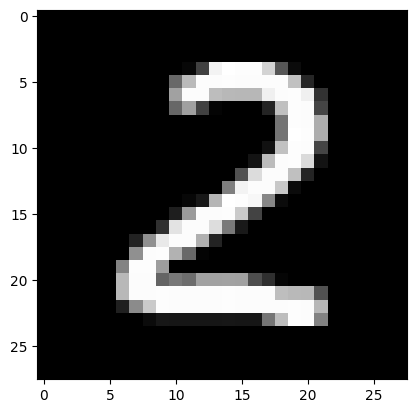

In [32]:
# check image
i = 0
print("index : " + str(i))
print("label : ", train_labels_random[i])
print("image")    
plt.imshow(train_images_random[i], cmap='gray')
plt.show()

In [33]:
# normalization
train_images_random = train_images_random/255.0
valid_images_random = valid_images_random/255.0
test_images = test_images/255.0

In [34]:
# dataset with normalization
class MnistSequence(tf.keras.utils.Sequence):
        
    def __init__(self, images ,labels, batch_size):
        self.x = images
        self.y = labels
        self.indices = np.arange(len(self.x))
        self.batch_size = batch_size
        self.steps_per_epoch = int(np.ceil(len(self.x) / self.batch_size))

    def __len__(self):
        return self.steps_per_epoch

    def __getitem__(self, idx):
        inds = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_x = self.x[inds]
        batch_y = self.y[inds]

        return np.array(batch_x), np.array(batch_y)
    
    def on_epoch_end(self):
        pass

In [35]:
datasets_train = MnistSequence(train_images_random,train_labels_random, batch_size=32) # batch_index, image or labels , index
datasets_valid = MnistSequence(valid_images_random,valid_labels_random, batch_size=32) # batch_index, image or labels , index
datasets_test = MnistSequence(test_images,test_labels, batch_size=1) # batch_index, image or labels , index

index : 10
label :  0
image


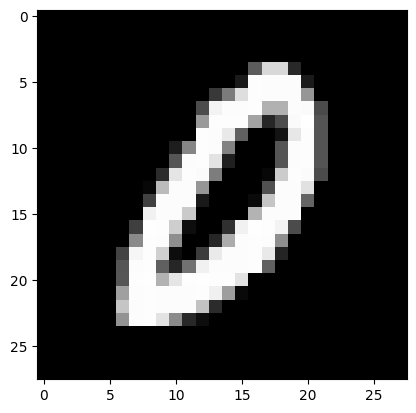

In [36]:
# check dataset label
bi = 2
i = 10
print("index : " + str(i))
print("label : ", datasets_train[bi][1][i])
print("image")    
plt.imshow(datasets_train[bi][0][i], cmap='gray')
plt.show()

In [37]:
# input shape
input_shape=(28,28,1)

In [38]:
config = [3, 'M','Cl']

In [39]:
def make_classification_layers(dense = 4096, num_classes=10):
    classification_layers = tf.keras.models.Sequential([
                            tf.keras.layers.Flatten(),
                            tf.keras.layers.Dense(dense, activation='relu'),
                            tf.keras.layers.Dense(dense, activation='relu'),
                            tf.keras.layers.Dense(num_classes,activation=tf.keras.activations.softmax)
                            ],name='classification_layers')
    return classification_layers

In [40]:
def make_cbr_layers(v):
    cbr_layers = tf.keras.models.Sequential([
                            tf.keras.layers.Conv2D(v,kernel_size=(3,3),strides=(1, 1),padding='same'),
                            tf.keras.layers.BatchNormalization(),
                            tf.keras.layers.ReLU()
                            ])
    return cbr_layers

In [41]:
def make_layers(config,dense =4096, num_class=10):
    layers = []
    for v in config:
        if v == 'M':
            layers += [tf.keras.layers.MaxPooling2D(pool_size=(2, 2),strides=None,padding='same')]
        elif v == 'Cl':
            layers += [make_classification_layers(dense,num_class)]
        else:
            layers += [make_cbr_layers(v)]
    return tf.keras.models.Sequential(layers)

In [42]:
# create model
model = make_layers(config,dense =50, num_class=10)

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 sequential_2 (Sequential)   (None, 28, 28, 3)         42        
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 3)         0         
 g2D)                                                            
                                                                 
 classification_layers (Seq  (None, 10)                32510     
 uential)                                                        
                                                                 
Total params: 32552 (127.16 KB)
Trainable params: 32546 (127.13 KB)
Non-trainable params: 6 (24.00 Byte)
_________________________________________________________________


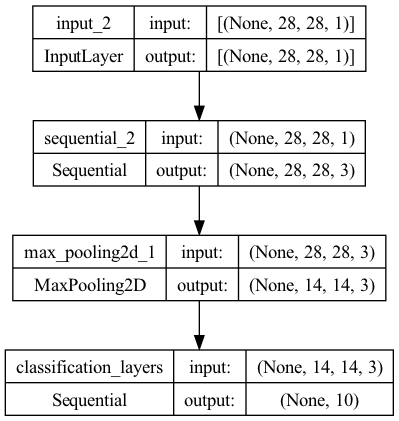

In [43]:
def get_functional_model(model):
    x = tf.keras.layers.Input(shape=(input_shape))
    model = tf.keras.Model(inputs=[x],outputs=model.call(x))
    return model

functional_model = get_functional_model(model)

functional_model.summary()
with open("model_summary.txt", "w") as fp:
    functional_model.summary(print_fn=lambda x: fp.write(x + "\r\n"))

tf.keras.utils.plot_model(functional_model, show_shapes=True, show_layer_names=True, to_file='model.png')
from IPython.display import Image
Image(retina=False, filename='model.png')

In [44]:
# define loss
criterion = tf.keras.losses.SparseCategoricalCrossentropy()
# define optimizer
optimizer = tf.keras.optimizers.Adam()

In [45]:
# compile model
model.compile(loss=criterion, optimizer=optimizer, metrics=['accuracy'])

In [ ]:
# training
history = model.fit(datasets_train,epochs=1,shuffle=True)

In [ ]:
# training
history = model.fit(datasets_train,validation_data=(valid_images_random, valid_labels_random),epochs=1,shuffle=True)

In [ ]:
# training
history = model.fit(datasets_train,validation_data=datasets_valid,epochs=1,shuffle=True)

In [ ]:
log_dir = './logs/fit/'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

In [ ]:
# training
history = model.fit(datasets_train,validation_data=datasets_valid,epochs=3,shuffle=True,callbacks=[tensorboard_callback])

In [61]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

In [ ]:
%tensorboard --logdir logs/fit

In [50]:
# Define our metrics
train_loss = tf.keras.metrics.Mean('train_loss', dtype=tf.float32)
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy('train_accuracy')
test_loss = tf.keras.metrics.Mean('test_loss', dtype=tf.float32)
test_accuracy = tf.keras.metrics.SparseCategoricalAccuracy('test_accuracy')

In [54]:
def train_step(model, optimizer, x_train, y_train):
    with tf.GradientTape() as tape:
        predictions = model(x_train, training=True)
        loss = criterion(y_train, predictions)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    train_loss(loss)
    train_accuracy(y_train, predictions)

def test_step(model, x_test, y_test):
    predictions = model(x_test)
    loss = criterion(y_test, predictions)

    test_loss(loss)
    test_accuracy(y_test, predictions)

In [55]:
import datetime
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
train_log_dir = 'logs/gradient_tape/' + current_time + '/train'
test_log_dir = 'logs/gradient_tape/' + current_time + '/test'
train_summary_writer = tf.summary.create_file_writer(train_log_dir)
test_summary_writer = tf.summary.create_file_writer(test_log_dir)

In [59]:
EPOCHS = 1

for epoch in range(EPOCHS):
    for (x_train, y_train) in datasets_train:
        train_step(model, optimizer, x_train, y_train)
    with train_summary_writer.as_default():
        tf.summary.scalar('loss', train_loss.result(), step=epoch)
        tf.summary.scalar('accuracy', train_accuracy.result(), step=epoch)

    for (x_test, y_test) in datasets_test:
        test_step(model, x_test, y_test)
    with test_summary_writer.as_default():
        tf.summary.scalar('loss', test_loss.result(), step=epoch)
        tf.summary.scalar('accuracy', test_accuracy.result(), step=epoch)

    template = 'Epoch {:3d}, Loss: {:e}, Accuracy: {:.2f}, Test Loss: {:e}, Test Accuracy: {:.2f}'
    print (template.format(epoch+1,
                          train_loss.result(), 
                          train_accuracy.result()*100,
                          test_loss.result(), 
                          test_accuracy.result()*100))

    # Reset metrics every epoch
    train_loss.reset_states()
    test_loss.reset_states()
    train_accuracy.reset_states()
    test_accuracy.reset_states()
print('Finished Training')

Epoch   1, Loss: 1.169808e-01, Accuracy: 96.35, Test Loss: 1.376654e-01, Test Accuracy: 95.98
Finished Training


In [62]:
%tensorboard --logdir logs/gradient_tape

Launching TensorBoard...

In [ ]:
# save model
model.save('my_model')

In [ ]:
# load model
model = tf.keras.models.load_model('my_model')

In [ ]:
# reset model
tf.keras.backend.clear_session()
del model

In [ ]:
# prediction
predictions = model(test_images)

In [ ]:
# check test label and prediction
i = 100
print("index : " + str(i))
print("label : ", test_labels[i])
print("predictions : ", np.argmax(predictions[i]))
print("image")    
plt.imshow(test_images[i], cmap='gray')
plt.show()

In [ ]:
# prediction
predictions = model.predict(datasets_test)

In [ ]:
# check test label and prediction
i = 100
print("index : " + str(i))
print("label : ", datasets_test[i][1])
print("predictions : ", np.argmax(predictions[i]))
print("image")    
plt.imshow(datasets_test[i][0][0], cmap='gray')
plt.show()

In [ ]:
# plot loss
train_loss = history.history['loss']
valid_loss = history.history['val_loss']
epochs = len(train_loss)
plt.plot(range(epochs), train_loss, marker='.', label='train loss')
plt.plot(range(epochs), valid_loss, marker='.', label='valid loss')
plt.grid()
plt.ylim([0,1])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [ ]:
# plot accuracy
train_accuracy = history.history['accuracy']
valid_accuracy = history.history['val_accuracy']
epochs = len(train_loss)
plt.plot(range(epochs), train_accuracy, marker='.', label='train accuracy')
plt.plot(range(epochs), valid_accuracy, marker='.', label='valid accuracy')
plt.grid()
plt.ylim([0,1])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()